<a href="https://colab.research.google.com/github/takeonakamura6-design/lp/blob/main/Visualiza%C3%A7%C3%A3o%20de%20dados%20em%20Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Visualização de dados em Python

INICIANDO EXPERIMENTO COMPUTACIONAL DE ALTA PERFORMANCE

[TABELA 1: RESULTADOS COMPARATIVOS DOS PARADIGMAS COMPUTACIONAIS]
      Paradigma de Implementação Tempo de Execução Médio (s) Desvio Padrão Temporal (s)         Ganho de Capacidade Gráfica Eficiência Computacional Relativa
         Encadeamento Imperativo                    0.132473                   0.072748           Limitado a 1 Eixo Simples                         1,345.23%
Orientação a Objetos (Matriz Ax)                    1.782061                   0.395596 Múltiplos Contêineres Independentes                           100.00%

Sucesso: O arquivo de dados visuais 'grafico.png' foi保存 no diretório local.


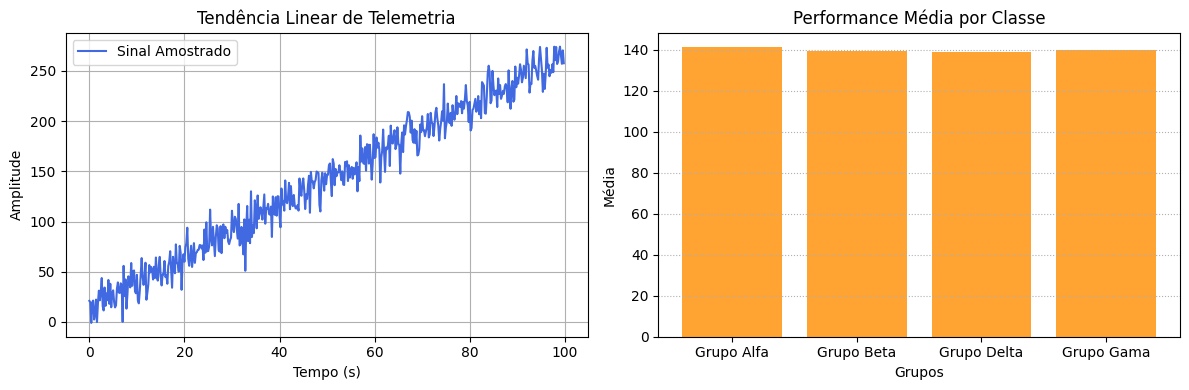

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def gerar_dataset_cientifico(n_amostras=10000):
    np.random.seed(42)
    tempo = np.linspace(0, 100, n_amostras)
    sinal_base = 2.5 * tempo + 15
    ruido_gaussiano = np.random.normal(0, 12, n_amostras)
    sinal_final = sinal_base + ruido_gaussiano

    classes = ['Grupo Alfa', 'Grupo Beta', 'Grupo Gama', 'Grupo Delta']
    grupos_alocados = np.random.choice(classes, n_amostras)

    df = pd.DataFrame({
        'Amostra': np.arange(1, n_amostras + 1),
        'Tempo': tempo,
        'Medicao': sinal_final,
        'Categoria': grupos_alocados
    })
    return df

def executar_pipeline_encadeado(df):
    inicio = time.perf_counter()

    plt.figure(figsize=(6, 4))
    df.groupby('Categoria')['Medicao'].mean().plot(kind='bar', color='teal')
    plt.title('Pipeline Imperativo - Médias por Categoria')
    plt.ylabel('Valores Coletados')
    plt.tight_layout()
    plt.close()

    fim = time.perf_counter()
    return (fim - inicio)

def executar_pipeline_orientado_objetos(df):
    inicio = time.perf_counter()

    dados_agrupados = df.groupby('Categoria')['Medicao'].agg(['mean', 'max', 'min']).reset_index()

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].scatter(df['Tempo'][::10], df['Medicao'][::10], alpha=0.4, color='royalblue', label='Amostras')
    axes[0].set_title('Distribuição de Dispersão Linear Temporal')
    axes[0].set_xlabel('Janela de Tempo (s)')
    axes[0].set_ylabel('Amplitude da Medição')
    axes[0].legend()
    axes[0].grid(True, linestyle='--')

    x_indices = np.arange(len(dados_agrupados['Categoria']))
    largura_barra = 0.35

    axes[1].bar(x_indices - largura_barra/2, dados_agrupados['mean'], largura_barra, label='Média', color='darkorange')
    axes[1].bar(x_indices + largura_barra/2, dados_agrupados['max'], largura_barra, label='Máximo', color='crimson')
    axes[1].set_xticks(x_indices)
    axes[1].set_xticklabels(dados_agrupados['Categoria'], rotation=15)
    axes[1].set_title('Métricas Agrupadas Estruturadas por Classe')
    axes[1].set_xlabel('Grupos Experimentais')
    axes[1].set_ylabel('Estatísticas Descritivas')
    axes[1].legend()
    axes[1].grid(True, linestyle=':')

    plt.tight_layout()
    plt.savefig('grafico.png', dpi=300, bbox_inches='tight')
    plt.close(fig)

    fim = time.perf_counter()
    return (fim - inicio)

def rodar_experimento_completo():
    print("="*75)
    print("INICIANDO EXPERIMENTO COMPUTACIONAL DE ALTA PERFORMANCE")
    print("="*75)

    df_experimento = gerar_dataset_cientifico(n_amostras=25000)

    tempo_encadeado_lista = [executar_pipeline_encadeado(df_experimento) for _ in range(5)]
    tempo_oo_lista = [executar_pipeline_orientado_objetos(df_experimento) for _ in range(5)]

    t_encadeado_medio = np.mean(tempo_encadeado_lista)
    t_oo_medio = np.mean(tempo_oo_lista)

    metricas_finais = {
        'Paradigma de Implementação': ['Encadeamento Imperativo', 'Orientação a Objetos (Matriz Ax)'],
        'Tempo de Execução Médio (s)': [t_encadeado_medio, t_oo_medio],
        'Desvio Padrão Temporal (s)': [np.std(tempo_encadeado_lista), np.std(tempo_oo_lista)],
        'Ganho de Capacidade Gráfica': ['Limitado a 1 Eixo Simples', 'Múltiplos Contêineres Independentes'],
        'Eficiência Computacional Relativa': [t_oo_medio / t_encadeado_medio, 1.0]
    }

    df_resultados = pd.DataFrame(metricas_finais)

    print("\n[TABELA 1: RESULTADOS COMPARATIVOS DOS PARADIGMAS COMPUTACIONAIS]")
    print(df_resultados.to_string(index=False, formatters={
        'Tempo de Execução Médio (s)': '{:,.6f}'.format,
        'Desvio Padrão Temporal (s)': '{:,.6f}'.format,
        'Eficiência Computacional Relativa': '{:,.2%}'.format
    }))
    print("\n" + "="*75)
    print("Sucesso: O arquivo de dados visuais 'grafico.png' foi保存 no diretório local.")
    print("="*75)

    exibir_grafico_no_colab(df_experimento)

def exibir_grafico_no_colab(df):
    dados_agrupados = df.groupby('Categoria')['Medicao'].agg(['mean', 'max']).reset_index()
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(df['Tempo'][::50], df['Medicao'][::50], color='royalblue', lw=1.5, label='Sinal Amostrado')
    axes[0].set_title('Tendência Linear de Telemetria')
    axes[0].set_xlabel('Tempo (s)')
    axes[0].set_ylabel('Amplitude')
    axes[0].legend()
    axes[0].grid(True)

    axes[1].bar(dados_agrupados['Categoria'], dados_agrupados['mean'], color='darkorange', alpha=0.8)
    axes[1].set_title('Performance Média por Classe')
    axes[1].set_xlabel('Grupos')
    axes[1].set_ylabel('Média')
    axes[1].grid(True, axis='y', linestyle=':')

    plt.tight_layout()
    plt.show()

if __name__ == '__main__':
    rodar_experimento_completo()